# 05. Sequential Backtest

04의 out-of-sample 확률을 시간순으로 재생해 겹치는 1분 신호를 독립 거래로 계산하던 문제를 제거한다.

고정 전략 목적:

- 차트 기반 가격·시간 feature만 사용
- TP `+5%`, SL `-3%`, 최대 보유 `10분`
- 첫 미래 1분봉까지만 주문 유효
- 동일 종목의 주문 또는 포지션이 활성화된 동안 재진입 금지
- validation에서 threshold를 선택하고 test에는 그대로 적용
- dual-path 결과가 다른 `AMBIGUOUS` 표본은 평가에서 제외

In [1]:
from __future__ import annotations

import json
import math
import sys
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 150)
plt.style.use("seaborn-v0_8-whitegrid") if "seaborn-v0_8-whitegrid" in plt.style.available else None

assert "envs/urban" in str(Path(sys.executable).resolve()), f"urban 환경이 아닙니다: {sys.executable}"
print(f"python: {sys.executable}")
print(f"torch: {torch.__version__}")


python: /home/user/anaconda3/envs/urban/bin/python
torch: 2.9.1+cu128


## 1. Prediction과 체결 라벨 결합

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "AGENT.md").exists() and (candidate / "README.md").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = (PROJECT_ROOT / "../../data/stock_data").resolve()
PROCESSED_ROOT = DATA_ROOT / "processed"
BACKTEST_ROOT = DATA_ROOT / "backtests"
BACKTEST_ROOT.mkdir(parents=True, exist_ok=True)

PREDICTIONS_PATH = PROCESSED_ROOT / "baseline_torch_predictions_10m_tp5_sl3_price_v2.parquet"
LABELS_PATH = PROCESSED_ROOT / "labels_dual_path_10m_tp5_sl3_v2.parquet"
MODEL_THRESHOLD_PATH = PROCESSED_ROOT / "baseline_torch_threshold_metrics_10m_tp5_sl3_price_v2.parquet"
for path in [PREDICTIONS_PATH, LABELS_PATH, MODEL_THRESHOLD_PATH]:
    assert path.exists(), f"필수 artifact가 없습니다: {path}"

predictions = pd.read_parquet(PREDICTIONS_PATH)
labels = pd.read_parquet(LABELS_PATH)
model_thresholds = pd.read_parquet(MODEL_THRESHOLD_PATH)
MERGE_KEYS = ["source_path", "symbol", "input_end_timestamp"]
execution_columns = [
    *MERGE_KEYS, "reference_close", "tick_size", "entry_price", "shares",
    "dual_agreement_10m", "outcome_hf_10m", "outcome_lf_10m",
    "event_bar_hf_10m", "event_bar_lf_10m",
    "net_pnl_hf_10m", "net_pnl_lf_10m", "net_return_hf_10m", "net_return_lf_10m",
]
backtest_df = predictions.merge(labels[execution_columns], on=MERGE_KEYS, how="inner", validate="one_to_one")
assert len(backtest_df) == len(predictions) == len(labels)
assert backtest_df["input_end_timestamp"].dt.tz is not None
assert backtest_df.loc[backtest_df["dual_agreement_10m"], "outcome_hf_10m"].eq(backtest_df.loc[backtest_df["dual_agreement_10m"], "outcome_lf_10m"]).all()
assert np.allclose(
    backtest_df.loc[backtest_df["dual_agreement_10m"], "net_pnl_hf_10m"],
    backtest_df.loc[backtest_df["dual_agreement_10m"], "net_pnl_lf_10m"],
    rtol=0.0, atol=1e-9,
)
assert np.allclose(
    backtest_df.loc[backtest_df["dual_agreement_10m"], "net_return_hf_10m"],
    backtest_df.loc[backtest_df["dual_agreement_10m"], "net_return_lf_10m"],
    rtol=0.0, atol=1e-12,
)

backtest_df["entry_notional"] = backtest_df["entry_price"] * backtest_df["shares"]
buy_commission = np.floor(backtest_df["entry_notional"] * 0.001 * 100 + 0.5) / 100
backtest_df["capital_required"] = backtest_df["entry_notional"] + buy_commission
backtest_df["net_pnl"] = (backtest_df["net_pnl_hf_10m"] + backtest_df["net_pnl_lf_10m"]) / 2
backtest_df["net_return"] = (backtest_df["net_return_hf_10m"] + backtest_df["net_return_lf_10m"]) / 2
backtest_df["filled"] = backtest_df["outcome_hf_10m"].ne("NO_FILL")
event_bar_max = backtest_df[["event_bar_hf_10m", "event_bar_lf_10m"]].max(axis=1)
backtest_df["holding_minutes"] = np.where(backtest_df["filled"], event_bar_max, 1).astype(int)
backtest_df["release_timestamp"] = backtest_df["input_end_timestamp"] + pd.to_timedelta(backtest_df["holding_minutes"], unit="m")
backtest_df["price_tier"] = np.where(backtest_df["entry_price"].lt(1.0), "below_$1", "at_or_above_$1")

assert backtest_df.loc[backtest_df["filled"], "holding_minutes"].between(1, 10).all()
assert backtest_df.loc[~backtest_df["filled"], "holding_minutes"].eq(1).all()
assert backtest_df["capital_required"].between(0, 1_010).all()
display(backtest_df.groupby(["split", "dual_outcome_10m"]).size().unstack(fill_value=0))


dual_outcome_10m,AMBIGUOUS,NO_FILL,SL,TIMEOUT,TP
split,,,,,
test,16,8755,1985,3753,687
train,35,14088,3286,4612,1240
validation,21,5623,1630,2746,607


## 2. 순차 주문·포지션 정책

동시 신호는 확률 내림차순으로 처리한다. 주문 시점부터 종료 시점까지 자금과 슬롯을 예약한다. 미체결은 1분 후 원금 전액을 해제하고, 체결 거래는 저장된 수수료·슬리피지 반영 순수익률을 평가한다. 달러 금액은 동시 보유와 가용자금 제약 계산에만 사용한다.

In [3]:
@dataclass(frozen=True)
class BacktestConfig:
    initial_capital: float = 10_000.0
    max_concurrent_positions: int = 5
    order_notional_usd: float = 1_000.0
    order_ttl_minutes: int = 1
    max_holding_minutes: int = 10
    min_signals_above_threshold: int = 40
    min_filled_trades: int = 20
    min_validation_sessions: int = 2
    min_filled_trades_per_validation_session: int = 5
    min_profitable_validation_session_share: float = 1.0
    min_test_sessions: int = 3
    min_profitable_test_session_share: float = 2 / 3
    threshold_quantile_min: float = 0.50
    threshold_quantile_max: float = 0.995

CONFIG = BacktestConfig()
display(pd.Series(asdict(CONFIG), name="value").to_frame())


,value
initial_capital,10000.000000
max_concurrent_positions,5.000000
order_notional_usd,1000.000000
order_ttl_minutes,1.000000
max_holding_minutes,10.000000
min_signals_above_threshold,40.000000
min_filled_trades,20.000000
min_validation_sessions,2.000000
min_filled_trades_per_validation_session,5.000000
min_profitable_validation_session_share,1.000000


In [4]:
def build_equity_curve(ledger: pd.DataFrame, initial_capital: float) -> pd.DataFrame:
    if ledger.empty:
        return pd.DataFrame(columns=["release_timestamp", "net_pnl", "equity", "portfolio_return", "peak", "drawdown"])
    released = ledger.groupby("release_timestamp", as_index=False)["net_pnl"].sum().sort_values("release_timestamp")
    released["equity"] = initial_capital + released["net_pnl"].cumsum()
    released["portfolio_return"] = released["equity"] / initial_capital - 1.0
    released["peak"] = released["equity"].cummax().clip(lower=initial_capital)
    released["drawdown"] = released["equity"] / released["peak"] - 1.0
    return released


def summarize_backtest(ledger: pd.DataFrame, equity_curve: pd.DataFrame, signal_count: int, skipped: dict, config: BacktestConfig) -> dict:
    filled = ledger[ledger["filled"]] if not ledger.empty else ledger
    positive_pnl = filled.loc[filled["net_pnl"] > 0, "net_pnl"].sum() if not filled.empty else 0.0
    negative_pnl = -filled.loc[filled["net_pnl"] < 0, "net_pnl"].sum() if not filled.empty else 0.0
    total_net_pnl = float(filled["net_pnl"].sum()) if not filled.empty else 0.0
    deployed_capital = float(filled["capital_required"].sum()) if not filled.empty else 0.0
    return {
        "signals_above_threshold": int(signal_count),
        "order_attempts": int(len(ledger)),
        "filled_trades": int(len(filled)),
        "no_fill_orders": int((~ledger["filled"]).sum()) if not ledger.empty else 0,
        "tp_trades": int(filled["outcome"].eq("TP").sum()) if not filled.empty else 0,
        "sl_trades": int(filled["outcome"].eq("SL").sum()) if not filled.empty else 0,
        "timeout_trades": int(filled["outcome"].eq("TIMEOUT").sum()) if not filled.empty else 0,
        "tp_precision_given_fill": float(filled["outcome"].eq("TP").mean()) if not filled.empty else np.nan,
        "net_win_rate": float(filled["net_pnl"].gt(0).mean()) if not filled.empty else np.nan,
        "total_net_pnl": total_net_pnl,
        "return_on_initial_capital": total_net_pnl / config.initial_capital,
        "net_return_on_deployed_capital": total_net_pnl / deployed_capital if deployed_capital > 0 else np.nan,
        "mean_net_return_per_fill": float(filled["net_return"].mean()) if not filled.empty else np.nan,
        "median_net_return_per_fill": float(filled["net_return"].median()) if not filled.empty else np.nan,
        "mean_net_pnl_per_fill": float(filled["net_pnl"].mean()) if not filled.empty else np.nan,
        "profit_factor": float(positive_pnl / negative_pnl) if negative_pnl > 0 else (np.inf if positive_pnl > 0 else np.nan),
        "max_drawdown": float(equity_curve["drawdown"].min()) if not equity_curve.empty else 0.0,
        "round_trip_turnover": float(2 * filled["entry_notional"].sum() / config.initial_capital) if not filled.empty else 0.0,
        "mean_holding_minutes": float(filled["holding_minutes"].mean()) if not filled.empty else np.nan,
        "skipped_same_symbol": int(skipped["same_symbol"]),
        "skipped_position_limit": int(skipped["position_limit"]),
        "skipped_cash_limit": int(skipped["cash_limit"]),
    }


def run_sequential_backtest(frame: pd.DataFrame, split_name: str, score_column: str, threshold: float, config: BacktestConfig = CONFIG):
    eligible = frame.loc[
        frame["split"].eq(split_name)
        & frame["dual_agreement_10m"]
        & frame[score_column].ge(threshold)
    ].sort_values(["input_end_timestamp", score_column, "symbol"], ascending=[True, False, True])
    signal_count = len(eligible)
    cash = config.initial_capital
    active = []
    ledger_rows = []
    skipped = {"same_symbol": 0, "position_limit": 0, "cash_limit": 0}

    for timestamp, candidates in eligible.groupby("input_end_timestamp", sort=True):
        remaining = []
        for position in active:
            if position["release_timestamp"] <= timestamp:
                cash += position["capital_required"] + position["net_pnl"]
            else:
                remaining.append(position)
        active = remaining

        for row in candidates.itertuples(index=False):
            active_symbols = {position["symbol"] for position in active}
            if row.symbol in active_symbols:
                skipped["same_symbol"] += 1
                continue
            if len(active) >= config.max_concurrent_positions:
                skipped["position_limit"] += 1
                continue
            if cash + 1e-9 < row.capital_required:
                skipped["cash_limit"] += 1
                continue

            cash -= row.capital_required
            position = {
                "source_path": row.source_path,
                "session": row.session,
                "split": split_name,
                "symbol": row.symbol,
                "signal_timestamp": timestamp,
                "release_timestamp": row.release_timestamp,
                "score": float(getattr(row, score_column)),
                "threshold": float(threshold),
                "filled": bool(row.filled),
                "outcome": row.outcome_hf_10m,
                "holding_minutes": int(row.holding_minutes),
                "entry_price": float(row.entry_price),
                "entry_notional": float(row.entry_notional),
                "capital_required": float(row.capital_required),
                "net_pnl": float(row.net_pnl),
                "net_return": float(row.net_return),
                "price_tier": row.price_tier,
                "concurrent_after_order": len(active) + 1,
                "cash_after_reservation": cash,
            }
            active.append(position)
            ledger_rows.append(position.copy())

    for position in sorted(active, key=lambda item: item["release_timestamp"]):
        cash += position["capital_required"] + position["net_pnl"]

    ledger = pd.DataFrame(ledger_rows)
    equity_curve = build_equity_curve(ledger, config.initial_capital)
    metrics = summarize_backtest(ledger, equity_curve, signal_count, skipped, config)
    metrics.update({"split": split_name, "score_column": score_column, "threshold": float(threshold), "ending_cash": float(cash)})
    if not ledger.empty:
        assert ledger["concurrent_after_order"].le(config.max_concurrent_positions).all()
        assert ledger["holding_minutes"].between(1, config.max_holding_minutes).all()
        assert ledger["cash_after_reservation"].ge(-1e-6).all()
        for _, symbol_trades in ledger.sort_values("signal_timestamp").groupby("symbol"):
            previous_release = symbol_trades["release_timestamp"].shift(1)
            assert symbol_trades.loc[previous_release.notna(), "signal_timestamp"].ge(previous_release.dropna().to_numpy()).all()
    assert math.isclose(cash, config.initial_capital + metrics["total_net_pnl"], rel_tol=0.0, abs_tol=1e-6)
    return metrics, ledger, equity_curve


## 3. Validation 전용 threshold 탐색

중복 제거 전 최소 신호 50건, 순차 처리 후 최소 체결 20건, 양의 평균 순수익률과 양의 포트폴리오 수익률, profit factor 1 초과를 모두 만족해야 `VALID`로 본다. threshold는 validation 평균 순수익률을 최우선으로 선택한다. 만족하는 값이 없으면 평균 순수익률이 가장 높은 값을 진단용으로만 사용하고 배포 가능 상태로 표시하지 않는다.

In [5]:
SCORE_COLUMNS = {
    "direct": "probability_direct",
    "two_stage": "probability_two_stage",
    "expected_return": "predicted_expected_net_return",
}
search_rows = []
selection_rows = []

for strategy, score_column in SCORE_COLUMNS.items():
    validation_scores = backtest_df.loc[
        backtest_df["split"].eq("validation") & backtest_df["dual_agreement_10m"], score_column
    ].to_numpy()
    quantiles = np.unique(np.concatenate([
        np.linspace(CONFIG.threshold_quantile_min, 0.95, 19),
        np.linspace(0.955, CONFIG.threshold_quantile_max, 17),
    ]))
    thresholds = np.unique(np.quantile(validation_scores, quantiles))
    threshold_from_04 = model_thresholds.loc[
        model_thresholds["score"].eq(strategy) & model_thresholds["split"].eq("validation"),
        "validation_top5_threshold",
    ].iloc[0]
    thresholds = np.unique(np.append(thresholds, threshold_from_04))

    for threshold in thresholds:
        metrics, _, _ = run_sequential_backtest(backtest_df, "validation", score_column, float(threshold))
        metrics["strategy"] = strategy
        validation_session_rows = []
        for session_name in sorted(backtest_df.loc[backtest_df['split'].eq('validation'), 'session'].unique()):
            session_metrics, _, _ = run_sequential_backtest(
                backtest_df.loc[backtest_df['session'].eq(session_name)],
                'validation', score_column, float(threshold),
            )
            validation_session_rows.append(session_metrics)
        validation_session_df = pd.DataFrame(validation_session_rows)
        profitable_mask = (
            validation_session_df['filled_trades'].ge(CONFIG.min_filled_trades_per_validation_session)
            & validation_session_df['mean_net_return_per_fill'].gt(0)
        )
        metrics['validation_sessions'] = len(validation_session_df)
        metrics['min_session_filled_trades'] = int(validation_session_df['filled_trades'].min())
        metrics['profitable_sessions'] = int(profitable_mask.sum())
        metrics['profitable_session_share'] = float(profitable_mask.mean())
        metrics['worst_session_mean_net_return'] = float(validation_session_df['mean_net_return_per_fill'].min())
        metrics["meets_constraints"] = (
            metrics["signals_above_threshold"] >= CONFIG.min_signals_above_threshold
            and metrics["filled_trades"] >= CONFIG.min_filled_trades
            and metrics['validation_sessions'] >= CONFIG.min_validation_sessions
            and metrics['min_session_filled_trades'] >= CONFIG.min_filled_trades_per_validation_session
            and metrics['profitable_session_share'] >= CONFIG.min_profitable_validation_session_share
            and metrics['worst_session_mean_net_return'] > 0
            and metrics["return_on_initial_capital"] > 0
            and metrics["profit_factor"] > 1
            and metrics["mean_net_return_per_fill"] > 0
        )
        search_rows.append(metrics)

    strategy_search = pd.DataFrame([row for row in search_rows if row["strategy"] == strategy])
    valid = strategy_search[strategy_search["meets_constraints"]]
    if len(valid):
        selected = valid.sort_values(["worst_session_mean_net_return", "mean_net_return_per_fill", "return_on_initial_capital"], ascending=[False, False, False]).iloc[0]
        selection_status = "VALID"
    else:
        candidates = strategy_search[strategy_search["filled_trades"].ge(CONFIG.min_filled_trades)]
        if candidates.empty:
            candidates = strategy_search[strategy_search["filled_trades"].gt(0)]
        selected = candidates.sort_values(["profitable_session_share", "worst_session_mean_net_return", "mean_net_return_per_fill"], ascending=[False, False, False]).iloc[0]
        selection_status = "NO_VALID_THRESHOLD"
    selection_rows.append({
        "strategy": strategy,
        "score_column": score_column,
        "selected_threshold": float(selected["threshold"]),
        "selection_status": selection_status,
        "validation_mean_net_return": float(selected["mean_net_return_per_fill"]),
        "validation_portfolio_return": float(selected["return_on_initial_capital"]),
        "validation_profit_factor": float(selected["profit_factor"]),
        "validation_filled_trades": int(selected["filled_trades"]),
        "validation_profitable_session_share": float(selected['profitable_session_share']),
        "validation_worst_session_mean_net_return": float(selected['worst_session_mean_net_return']),
    })

threshold_search_df = pd.DataFrame(search_rows)
selected_threshold_df = pd.DataFrame(selection_rows)
display(selected_threshold_df.set_index("strategy"))
display(threshold_search_df.groupby("strategy")["meets_constraints"].sum().rename("valid_threshold_count").to_frame())


,score_column,selected_threshold,selection_status,validation_mean_net_return,validation_portfolio_return,validation_profit_factor,validation_filled_trades,validation_profitable_session_share,validation_worst_session_mean_net_return
strategy,,,,,,,,,
direct,probability_direct,0.349172,NO_VALID_THRESHOLD,-0.004915,-0.020671,0.769562,42,0.5,-0.016240
two_stage,probability_two_stage,0.308607,NO_VALID_THRESHOLD,-0.006277,-0.036420,0.708822,58,0.5,-0.017595
expected_return,predicted_expected_net_return,0.002562,NO_VALID_THRESHOLD,-0.003426,-0.015436,0.796222,45,0.0,-0.003969


,valid_threshold_count
strategy,
direct,0
expected_return,0
two_stage,0


## 4. 고정 threshold의 validation·test 순차 결과

In [6]:
metric_rows = []
ledger_frames = []
equity_frames = []

for selected in selected_threshold_df.itertuples(index=False):
    for split_name in ["validation", "test"]:
        metrics, ledger, equity = run_sequential_backtest(
            backtest_df, split_name, selected.score_column, selected.selected_threshold
        )
        metrics["strategy"] = selected.strategy
        metrics["selection_status"] = selected.selection_status
        metrics["validation_eligible"] = selected.selection_status == "VALID"
        metric_rows.append(metrics)
        if not ledger.empty:
            ledger["strategy"] = selected.strategy
            ledger["selection_status"] = selected.selection_status
            ledger_frames.append(ledger)
        if not equity.empty:
            equity["strategy"] = selected.strategy
            equity["split"] = split_name
            equity_frames.append(equity)

backtest_metrics_df = pd.DataFrame(metric_rows)
test_session_rows = []
for selected in selected_threshold_df.itertuples(index=False):
    for session_name in sorted(backtest_df.loc[backtest_df['split'].eq('test'), 'session'].unique()):
        session_metrics, _, _ = run_sequential_backtest(
            backtest_df.loc[backtest_df['session'].eq(session_name)],
            'test', selected.score_column, selected.selected_threshold,
        )
        session_metrics.update({'strategy': selected.strategy, 'session': session_name})
        test_session_rows.append(session_metrics)
test_session_eval_df = pd.DataFrame(test_session_rows)
deployment_rows = []
for strategy in SCORE_COLUMNS:
    strategy_metrics = backtest_metrics_df[backtest_metrics_df["strategy"].eq(strategy)].set_index("split")
    validation_eligible = bool(strategy_metrics.loc["validation", "validation_eligible"])
    test_row = strategy_metrics.loc["test"]
    strategy_sessions = test_session_eval_df[test_session_eval_df['strategy'].eq(strategy)]
    profitable_session_mask = (
        strategy_sessions['filled_trades'].ge(CONFIG.min_filled_trades_per_validation_session)
        & strategy_sessions['mean_net_return_per_fill'].gt(0)
    )
    test_profitable_session_share = float(profitable_session_mask.mean())
    test_worst_session_mean_return = float(strategy_sessions['mean_net_return_per_fill'].min())
    test_return_pass = (
        test_row["mean_net_return_per_fill"] > 0
        and test_row["return_on_initial_capital"] > 0
        and test_row["profit_factor"] > 1
        and len(strategy_sessions) >= CONFIG.min_test_sessions
        and test_profitable_session_share >= CONFIG.min_profitable_test_session_share
    )
    deployment_rows.append({
        "strategy": strategy,
        "validation_eligible": validation_eligible,
        "test_return_pass": bool(test_return_pass),
        "test_sessions": len(strategy_sessions),
        "test_profitable_session_share": test_profitable_session_share,
        "test_worst_session_mean_net_return": test_worst_session_mean_return,
        "deployment_status": "PASS" if validation_eligible and test_return_pass else "FAIL",
    })
deployment_status_df = pd.DataFrame(deployment_rows)
trade_ledger_df = pd.concat(ledger_frames, ignore_index=True) if ledger_frames else pd.DataFrame()
equity_curve_df = pd.concat(equity_frames, ignore_index=True) if equity_frames else pd.DataFrame()
metric_columns = [
    "strategy", "split", "selection_status", "threshold", "signals_above_threshold",
    "order_attempts", "filled_trades", "tp_precision_given_fill",
    "mean_net_return_per_fill", "median_net_return_per_fill",
    "net_return_on_deployed_capital", "return_on_initial_capital",
    "total_net_pnl", "profit_factor",
    "max_drawdown", "round_trip_turnover", "mean_holding_minutes",
    "skipped_same_symbol", "skipped_position_limit", "skipped_cash_limit",
]
display(backtest_metrics_df[metric_columns].set_index(["strategy", "split"]))
display(deployment_status_df.set_index("strategy"))
assert backtest_df.loc[backtest_df["split"].eq("validation"), "input_end_timestamp"].max() < backtest_df.loc[backtest_df["split"].eq("test"), "input_end_timestamp"].min()


selection_status  threshold  \
strategy        split                                       
direct          validation  NO_VALID_THRESHOLD   0.349172   
                test        NO_VALID_THRESHOLD   0.349172   
two_stage       validation  NO_VALID_THRESHOLD   0.308607   
                test        NO_VALID_THRESHOLD   0.308607   
expected_return validation  NO_VALID_THRESHOLD   0.002562   
                test        NO_VALID_THRESHOLD   0.002562   

                            signals_above_threshold  order_attempts  \
strategy        split                                                 
direct          validation                       54              47   
                test                             48              40   
two_stage       validation                       80              65   
                test                             67              57   
expected_return validation                      107              68   
                test                            190             117   

                            filled_trades  tp_precision_given_fill  \
strategy        split                                                
direct          validation             42                 0.333333   
                test                   30                 0.266667   
two_stage       validation             58                 0.310345   
                test                   47                 0.234043   
expected_return validation             45                 0.266667   
                test                   57                 0.245614   

                            mean_net_return_per_fill  \
strategy        split                                  
direct          validation                 -0.004915   
                test                       -0.011993   
two_stage       validation                 -0.006277   
                test                       -0.013426   
expected_return validation                 -0.003426   
                test                       -0.006288   

                            median_net_return_per_fill  \
strategy        split                                    
direct          validation                   -0.033049   
                test                         -0.033078   
two_stage       validation                   -0.032963   
                test                         -0.033078   
expected_return validation                   -0.018204   
                test                         -0.032941   

                            net_return_on_deployed_capital  \
strategy        split                                        
direct          validation                       -0.004921   
                test                             -0.011993   
two_stage       validation                       -0.006280   
                test                             -0.013430   
expected_return validation                       -0.003435   
                test                             -0.006298   

                            return_on_initial_capital  total_net_pnl  \
strategy        split                                                  
direct          validation                  -0.020671    -206.705873   
                test                        -0.035995    -359.954277   
two_stage       validation                  -0.036420    -364.198265   
                test                        -0.063139    -631.387588   
expected_return validation                  -0.015436    -154.361124   
                test                        -0.035860    -358.602301   

                            profit_factor  max_drawdown  round_trip_turnover  \
strategy        split                                                          
direct          validation       0.769562     -0.029864             8.392808   
                test             0.507741     -0.047589             5.996513   
two_stage       validation       0.708822     -0.043279            11.586203   
                test   

,validation_eligible,test_return_pass,test_sessions,test_profitable_session_share,test_worst_session_mean_net_return,deployment_status
strategy,,,,,,
direct,False,False,3,0.000000,-0.013950,FAIL
two_stage,False,False,3,0.000000,-0.013853,FAIL
expected_return,False,False,3,0.333333,-0.018679,FAIL


## 5. 세션·종목·가격대 안정성

,strategy,split,session,trades,symbols,tp_precision,mean_net_return,median_net_return,total_net_pnl,mean_net_pnl
0,direct,test,session_2026-07-15,25,5,0.240000,-0.013950,-0.033078,-348.911535,-13.956461
1,direct,test,session_2026-07-16,5,1,0.400000,-0.002206,-0.034036,-11.042742,-2.208548
2,direct,validation,session_2026-07-13,28,4,0.392857,0.000747,-0.032963,20.963958,0.748713
3,direct,validation,session_2026-07-14,14,3,0.214286,-0.016240,-0.033188,-227.669831,-16.262131
4,expected_return,test,session_2026-07-15,36,11,0.305556,-0.003294,-0.019773,-119.097091,-3.308253
5,expected_return,test,session_2026-07-16,13,4,0.076923,-0.018679,-0.032985,-242.585265,-18.660405
6,expected_return,test,session_2026-07-17,8,5,0.250000,0.000376,-0.008861,3.080055,0.385007
7,expected_return,validation,session_2026-07-13,29,9,0.275862,-0.003969,-0.019299,-115.448552,-3.980985
8,expected_return,validation,session_2026-07-14,16,6,0.250000,-0.002442,-0.011272,-38.912571,-2.432036
9,two_stage,test,session_2026-07-15,38,6,0.236842,-0.013853,-0.033069,-526.683114,-13.860082


,strategy,split,price_tier,trades,tp_precision,mean_net_return,median_net_return,total_net_pnl,mean_net_pnl
0,direct,test,at_or_above_$1,21,0.190476,-0.017887,-0.033078,-375.820614,-17.896220
1,direct,test,below_$1,9,0.444444,0.001760,-0.033128,15.866336,1.762926
2,direct,validation,at_or_above_$1,12,0.416667,0.000230,-0.032961,2.639696,0.219975
3,direct,validation,below_$1,30,0.300000,-0.006973,-0.033177,-209.345569,-6.978186
4,expected_return,test,at_or_above_$1,41,0.195122,-0.010260,-0.032959,-420.895570,-10.265746
5,expected_return,test,below_$1,16,0.375000,0.003891,-0.006401,62.293269,3.893329
6,expected_return,validation,at_or_above_$1,30,0.233333,-0.008516,-0.029095,-255.707230,-8.523574
7,expected_return,validation,below_$1,15,0.333333,0.006753,-0.002672,101.346106,6.756407
8,two_stage,test,at_or_above_$1,29,0.241379,-0.013808,-0.033057,-400.626464,-13.814706
9,two_stage,test,below_$1,18,0.222222,-0.012812,-0.033143,-230.761123,-12.820062


,strategy,split,symbol,trades,mean_net_return,median_net_return,total_net_pnl,mean_net_pnl
0,direct,test,CNEY,1,0.046513,0.046513,46.558811,46.558811
2,direct,test,JTAI,2,0.006898,0.006898,13.668866,6.834433
4,direct,test,SOBR,2,0.006782,0.006782,13.601479,6.800740
3,direct,test,LIMN,5,-0.002206,-0.034036,-11.042742,-2.208548
5,direct,test,TGHL,13,-0.020834,-0.033089,-270.935261,-20.841174
11,direct,validation,SOBR,11,0.010319,0.046512,113.550556,10.322778
10,direct,validation,NXTC,2,0.006920,0.006920,13.672376,6.836188
6,direct,validation,AGEN,5,-0.001060,-0.032961,-5.285172,-1.057034
9,direct,validation,JEM,8,-0.004356,-0.033223,-34.859583,-4.357448
12,direct,validation,VMAR,4,-0.013109,-0.033044,-52.441843,-13.110461


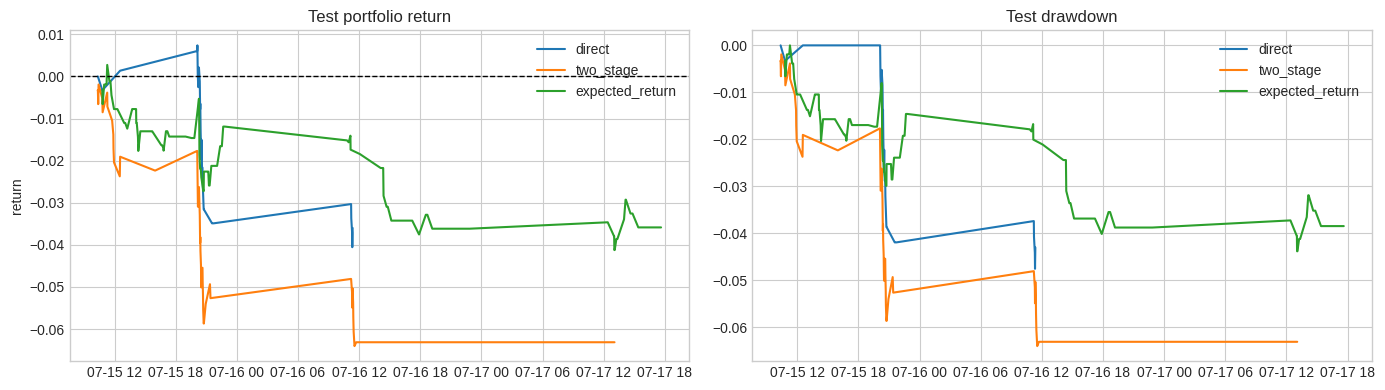

In [7]:
filled_ledger = trade_ledger_df[trade_ledger_df["filled"]].copy()
session_summary = filled_ledger.groupby(["strategy", "split", "session"]).agg(
    trades=("symbol", "size"),
    symbols=("symbol", "nunique"),
    tp_precision=("outcome", lambda values: values.eq("TP").mean()),
    mean_net_return=("net_return", "mean"),
    median_net_return=("net_return", "median"),
    total_net_pnl=("net_pnl", "sum"),
    mean_net_pnl=("net_pnl", "mean"),
).reset_index()
price_summary = filled_ledger.groupby(["strategy", "split", "price_tier"]).agg(
    trades=("symbol", "size"),
    tp_precision=("outcome", lambda values: values.eq("TP").mean()),
    mean_net_return=("net_return", "mean"),
    median_net_return=("net_return", "median"),
    total_net_pnl=("net_pnl", "sum"),
    mean_net_pnl=("net_pnl", "mean"),
).reset_index()
symbol_summary = filled_ledger.groupby(["strategy", "split", "symbol"]).agg(
    trades=("symbol", "size"),
    mean_net_return=("net_return", "mean"),
    median_net_return=("net_return", "median"),
    total_net_pnl=("net_pnl", "sum"),
    mean_net_pnl=("net_pnl", "mean"),
).reset_index().sort_values(["strategy", "split", "mean_net_return"], ascending=[True, True, False])
display(session_summary)
display(price_summary)
display(symbol_summary.groupby(["strategy", "split"]).head(5))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for strategy in SCORE_COLUMNS:
    curve = equity_curve_df[(equity_curve_df["strategy"].eq(strategy)) & (equity_curve_df["split"].eq("test"))]
    axes[0].plot(curve["release_timestamp"], curve["portfolio_return"], label=strategy)
    axes[1].plot(curve["release_timestamp"], curve["drawdown"], label=strategy)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Test portfolio return")
axes[0].set_ylabel("return")
axes[1].set_title("Test drawdown")
for axis in axes:
    axis.legend()
plt.tight_layout()
plt.show()


## 6. Artifact 저장 및 무결성 검사

In [8]:
SEARCH_PATH = BACKTEST_ROOT / "threshold_search_10m_tp5_sl3.parquet"
SELECTED_THRESHOLD_PATH = BACKTEST_ROOT / "selected_thresholds_10m_tp5_sl3.parquet"
METRICS_PATH = BACKTEST_ROOT / "sequential_metrics_10m_tp5_sl3.parquet"
DEPLOYMENT_STATUS_PATH = BACKTEST_ROOT / "sequential_deployment_status_10m_tp5_sl3.parquet"
LEDGER_PATH = BACKTEST_ROOT / "sequential_trade_ledger_10m_tp5_sl3.parquet"
EQUITY_PATH = BACKTEST_ROOT / "sequential_equity_10m_tp5_sl3.parquet"
SESSION_PATH = BACKTEST_ROOT / "sequential_session_summary_10m_tp5_sl3.parquet"
TEST_SESSION_GATE_PATH = BACKTEST_ROOT / "sequential_test_session_gate_10m_tp5_sl3.parquet"
PRICE_PATH = BACKTEST_ROOT / "sequential_price_summary_10m_tp5_sl3.parquet"
SYMBOL_PATH = BACKTEST_ROOT / "sequential_symbol_summary_10m_tp5_sl3.parquet"
CONFIG_PATH = BACKTEST_ROOT / "sequential_backtest_10m_tp5_sl3_config.json"

threshold_search_df.to_parquet(SEARCH_PATH, index=False, compression="zstd")
selected_threshold_df.to_parquet(SELECTED_THRESHOLD_PATH, index=False, compression="zstd")
backtest_metrics_df.to_parquet(METRICS_PATH, index=False, compression="zstd")
deployment_status_df.to_parquet(DEPLOYMENT_STATUS_PATH, index=False, compression="zstd")
trade_ledger_df.to_parquet(LEDGER_PATH, index=False, compression="zstd")
equity_curve_df.to_parquet(EQUITY_PATH, index=False, compression="zstd")
session_summary.to_parquet(SESSION_PATH, index=False, compression="zstd")
test_session_eval_df.to_parquet(TEST_SESSION_GATE_PATH, index=False, compression="zstd")
price_summary.to_parquet(PRICE_PATH, index=False, compression="zstd")
symbol_summary.to_parquet(SYMBOL_PATH, index=False, compression="zstd")
CONFIG_PATH.write_text(json.dumps({
    "environment": "urban",
    "python": sys.version.split()[0],
    "torch": torch.__version__,
    "label_version": "dual_path_10m_tp5_sl3_v2",
    "threshold_source": "validation_only",
    "ambiguous_policy": "exclude",
    "dual_path_exit_time_policy": "conservative_max_event_bar",
    "validation_gate": "aggregate constraints plus every validation session profitable",
    "test_gate": "aggregate constraints plus at least two of three test sessions profitable",
    "score_columns": SCORE_COLUMNS,
    "config": asdict(CONFIG),
}, ensure_ascii=False, indent=2), encoding="utf-8")

artifact_paths = [SEARCH_PATH, SELECTED_THRESHOLD_PATH, METRICS_PATH, DEPLOYMENT_STATUS_PATH, LEDGER_PATH, EQUITY_PATH, SESSION_PATH, TEST_SESSION_GATE_PATH, PRICE_PATH, SYMBOL_PATH, CONFIG_PATH]
assert all(path.exists() for path in artifact_paths)
assert not trade_ledger_df["outcome"].eq("AMBIGUOUS").any()
assert set(backtest_metrics_df["split"]) == {"validation", "test"}
assert set(backtest_metrics_df["strategy"]) == set(SCORE_COLUMNS)
print("PASS: validation-only threshold, sequential position, capital, horizon 및 artifact 검사")
display(pd.DataFrame({"artifact": artifact_paths, "size_kb": [path.stat().st_size / 1024 for path in artifact_paths]}))


PASS: validation-only threshold, sequential position, capital, horizon 및 artifact 검사


,artifact,size_kb
0,/home/user/urbandatalab/YSLee/data/stock_data/...,37.620117
1,/home/user/urbandatalab/YSLee/data/stock_data/...,7.611328
2,/home/user/urbandatalab/YSLee/data/stock_data/...,19.400391
3,/home/user/urbandatalab/YSLee/data/stock_data/...,4.907227
4,/home/user/urbandatalab/YSLee/data/stock_data/...,33.042969
5,/home/user/urbandatalab/YSLee/data/stock_data/...,16.423828
6,/home/user/urbandatalab/YSLee/data/stock_data/...,6.970703
7,/home/user/urbandatalab/YSLee/data/stock_data/...,19.024414
8,/home/user/urbandatalab/YSLee/data/stock_data/...,6.338867
9,/home/user/urbandatalab/YSLee/data/stock_data/...,7.440430


In [9]:
validation_results = backtest_metrics_df[backtest_metrics_df["split"].eq("validation")].set_index("strategy")
test_results = backtest_metrics_df[backtest_metrics_df["split"].eq("test")].set_index("strategy")
deployment_results = deployment_status_df.set_index("strategy")
findings = []
for strategy in SCORE_COLUMNS:
    validation_row = validation_results.loc[strategy]
    test_row = test_results.loc[strategy]
    findings.append(
        f"**{strategy}:** validation 평균 거래 순수익률 {validation_row['mean_net_return_per_fill']:.3%} → "
        f"test {test_row['mean_net_return_per_fill']:.3%}, test 포트폴리오 수익률 {test_row['return_on_initial_capital']:.2%}, "
        f"MDD {test_row['max_drawdown']:.2%}, 최종 판정 `{deployment_results.loc[strategy, 'deployment_status']}`."
    )
if deployment_status_df["deployment_status"].ne("PASS").any():
    findings.append("**배포 판정:** validation 적격성과 test 수익률 일반화를 모두 통과한 전략이 없으므로 현재 baseline은 배포 불가다.")
findings.extend([
    "**누수 방지:** threshold 탐색에는 validation만 사용했고 test 3일에는 고정값을 적용했다.",
    "**날짜 안정성:** validation 합산 수익뿐 아니라 두 validation 세션이 각각 양수인지 검사했고, test는 3개 세션 중 최소 2개의 양수 여부를 별도 기록했다.",
    "**다음 단계:** 수익성이 확인되지 않으면 threshold를 test에 맞춰 재조정하지 않고 feature·target·모델을 개선해야 한다.",
])
display(Markdown("### 실행 결론\n\n" + "\n\n".join(f"- {item}" for item in findings)))


### 실행 결론

- **direct:** validation 평균 거래 순수익률 -0.492% → test -1.199%, test 포트폴리오 수익률 -3.60%, MDD -4.76%, 최종 판정 `FAIL`.

- **two_stage:** validation 평균 거래 순수익률 -0.628% → test -1.343%, test 포트폴리오 수익률 -6.31%, MDD -6.41%, 최종 판정 `FAIL`.

- **expected_return:** validation 평균 거래 순수익률 -0.343% → test -0.629%, test 포트폴리오 수익률 -3.59%, MDD -4.39%, 최종 판정 `FAIL`.

- **배포 판정:** validation 적격성과 test 수익률 일반화를 모두 통과한 전략이 없으므로 현재 baseline은 배포 불가다.

- **누수 방지:** threshold 탐색에는 validation만 사용했고 test 3일에는 고정값을 적용했다.

- **날짜 안정성:** validation 합산 수익뿐 아니라 두 validation 세션이 각각 양수인지 검사했고, test는 3개 세션 중 최소 2개의 양수 여부를 별도 기록했다.

- **다음 단계:** 수익성이 확인되지 않으면 threshold를 test에 맞춰 재조정하지 않고 feature·target·모델을 개선해야 한다.